# import

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append("../General_Functions/")
from BasicData import *
from Flow_functions import * # import flow functions, Information to the agent
from Geometric_functions import * # Import rotation from euler angles
from Evolution_Traj import * # Import time integration for trjectories
from Time_Int_Traj import * # Import evolution function
from BasicData import *  # Nagents, R0, V
from Strategies import * # Import strategies, Braitenberg or Triangulation
from Strategies_Evolution import * # Import strategies Evolution, Braitenberg or Triangulation
from Flow_functions import * # Import flow functions: stokeslet, grads, strains ... 


In [2]:
# Integrate numerically the angular dynamics of each strategy
# Calculate the scalar product between t at the end of the evolution
# and the real source position

def Evolution(Grad):

    # Function to evaluate the scalar product between t at the end of the evolution
    # and the real source position
    #input:
    # Gradient (source flow measured)
    #output:
    # dot product as a 2D map
    # variance of dot product as 2D map
    
    # t axis for Triangulation strategy absence of roll
    t0_T, t1_T, t2_T = np.zeros((NPoints, NPoints, NTrials)), np.zeros((NPoints, NPoints, NTrials)), np.zeros((NPoints, NPoints, NTrials))
 
    # Resulting dot products
    DotProduct_T = np.zeros((NPoints, NPoints, NTrials))

    for k in range(NPoints):
        for i in range(NPoints):
            # Position the agent 
            AgentPosition =  np.array([z[k], x[i], 0.])

            # Source position
            OptimalDirection = -AgentPosition/np.linalg.norm(AgentPosition)

            for trials_i in range(NTrials):
                # Random orientation of agent axis
                alpha, beta, gamma = (2 * np.random.rand(3) - 1) * np.pi
                RotationMatrix = Rotation(alpha, np.abs(beta), gamma)

                n_T = np.dot(RotationMatrix,[0, 1, 0])
                b_T = np.dot(RotationMatrix,[0, 0, 1])
                t_T = np.dot(RotationMatrix,[1, 0, 0])

                # Time integration of strategies
                for time in range(Duration):
                    n_T, b_T, t_T, _ = Evolution_Triangulation(n_T, b_T, t_T, AntennaeLength, AgentPosition, Grad, e3, dt, 0, roll)
                   
                t0_T[k, i, trials_i], t1_T[k, i, trials_i], t2_T[k, i, trials_i] = t_T
               
                # Dot product Evaluation
                DotProduct_T[k, i, trials_i] = np.dot(t_T, OptimalDirection)
               

    return DotProduct_T, \
        t0_T, t1_T
       

In [11]:
# Data
NPoints = 30 # Grid number of points per axis
Duration = 255 # Number of timesteps of the numerical integration
NTrials = 1 # Number of trial x point

AntennaeLength = .01 # Sensors distance, on antennae
x = np.linspace(0.1, 5, NPoints) # x axis
z = np.linspace(0.1, 5, NPoints) # z axis

e3 = np.array([1, 0, 0]) # Source flow axis of symmetry, scheme zxy
dt = .1 # Timesteps 
roll = .4 # Roll Intensity
NameStrategies = ["T"] #"T",

In [12]:
# 

# Information flow 
GradName = ['GradientStresslet'] # 'ShearQuadruplet', 'GradientQuadruplet', 
Grads =  [GradientStresslet] # ShearQuadruplet, GradientQuadruplet


for grads_i, Grad in enumerate(Grads):
    # t axis for Triangulation strategy absence of roll
    t0_T, t1_T = np.zeros((NPoints, NPoints, NTrials)), np.zeros((NPoints, NPoints, NTrials))

    # Evaluate the strategy 2D map, vector P 
    Avg_P_T = np.zeros((NPoints, NPoints, NTrials))

    # Call Evaluation function and evaluate 
    Avg_P_T, t0_T, t1_T = Evolution(Grad)
    
    # Save data

    AllAvg = [Avg_P_T] #, Avg_P_T, Avg_P_I]
    Allt0 = [t0_T] # _not, t0_T, t0_I]
    Allt1 = [t1_T] # _not, t1_T, t1_I]

    for i, strat_name in enumerate(NameStrategies):
        np.savetxt("Data_NoNoise/"+str(GradName[grads_i])+"_Avg_"+str(strat_name)+"_test.txt", np.mean(AllAvg[i], axis = 2), delimiter = ',')
        np.savetxt("Data_NoNoise/"+str(GradName[grads_i])+"_t0_"+str(strat_name)+"_test.txt", np.mean(Allt0[i], axis = 2), delimiter = ',')
        np.savetxt("Data_NoNoise/"+str(GradName[grads_i])+"_t1_"+str(strat_name)+"_test.txt", np.mean(Allt1[i], axis = 2), delimiter = ',')

#plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


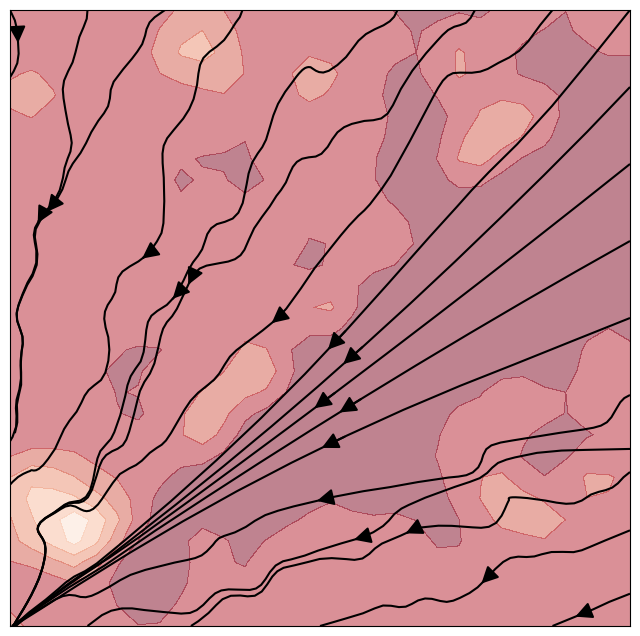

In [13]:
# Plot data from Save 
# Information flow 

import scipy.ndimage as ndimage # import to smooth plots
GradName = ['GradientStresslet'] # 'ShearQuadruplet', 'GradientQuadruplet', 
Grads =  [GradientStresslet] # ShearQuadruplet, GradientQuadruplet

for grads_i, Grad in enumerate(GradName):
    for i, strat_name in enumerate(NameStrategies):
        
        # Extract data from saved file
        with open("Data_NoNoise/"+str(GradName[grads_i])+"_Avg_"+str(strat_name)+"_test.txt", 'r') as the_file:
            Avg = np.array([np.asarray(each_line.split(",")).astype(float) for each_line in the_file]) 

        with open("Data_NoNoise/"+str(GradName[grads_i])+"_t0_"+str(strat_name)+"_test.txt", 'r') as the_file:

            t0 = np.array([np.asarray(each_line.split(",")).astype(float) for each_line in the_file]) 
        with open("Data_NoNoise/"+str(GradName[grads_i])+"_t1_"+str(strat_name)+"_test.txt", 'r') as the_file:

            t1 = np.array([np.asarray(each_line.split(",")).astype(float) for each_line in the_file]) 

        # Plot parameters
        CMAP = 'RdBu_r' #'spring'
        STREAMCOLOR = 'black'
        MIN_VALUE = -1
        MAX_VALUE = 1
        fig1, axs = plt.subplots(nrows=1, ncols=1, figsize=(8,8), sharex='col', sharey='row')
        ax1 = axs
        X, Z = np.meshgrid(x, z, indexing='xy')

        # Add data to image grid
        levels = np.linspace(-1, 1.00001, 14)

        Avg = ndimage.gaussian_filter(Avg, sigma=1.0, order=0)
        im = ax1.contourf(X, Z, Avg, cmap = CMAP, levels = levels, vmin= MIN_VALUE, vmax = MAX_VALUE, alpha = 0.5)
        ax1.streamplot(X, Z, t1, t0, color = STREAMCOLOR,  density = .3,  arrowsize = 2.5, broken_streamlines=False)
        #PlotCircles(ax1, .5)
        ax1.set_xlim([.1, 5])
        ax1.set_ylim([.1, 5])
        ax1.set_xticks([])
        ax1.set_yticks([])



        #plt.colorbar(im, ax = axs, ticks = np.arange(-1, 1.1, 0.5), location= 'bottom')
        # Uncomment to save
        plt.savefig("Plots_NoNoise/"+str(GradName[grads_i])+"_"+str(strat_name)+"_Numerical.eps", format = 'eps', bbox_inches='tight')
        plt.savefig("Plots_NoNoise/"+str(GradName[grads_i])+"_"+str(strat_name)+"_Numerical.pdf", bbox_inches='tight')
        plt.show()

# Add plot for the $\vec{e}_1$ vector

In [24]:
# tensor gradient in coordinates xyz
def Define_strain_eigenvectors(Grad, e3, AgentPosition):
    G = Grad(e3, AgentPosition)
    assert np.isclose(np.trace(G), 0), "gradient is not trace free"
    #assert np.allclose(G, np.transpose(G)), "gradient is not symmetric"

    # calculations of eigenvectors and relative eigenvalue a
    vaps, veps = np.linalg.eig(G[:-1,:-1])

    i_max = np.argmax(np.abs(vaps))
    s = np.sum(vaps) / vaps[i_max] - 1

    #if np.abs(G[2,2]) > np.max(np.abs(vaps)):
    #    print("Greater eigenvalue is along e_phi")

    # calculation of the trajectories of t as ellipses
    ymax = np.cos(0.5 * np.arccos(s / (2 + s)))
    zmax = np.cos(0.5 * np.arccos((s + 1) / (s - 1)))
    
    #print("gradient\n", G)
    #print("eigenvalues:", vaps, "   parameter a:", a)
    #print("ymax: ", ymax )
    #print("zmax: ", zmax)
    
    # construction of ellipses with 
    # n0 direction y (e_phi) 
    # n1 eigenvector associated to eigenvalue a
    # n2 main eigenvector (with eigenvalue 1)
    
    n0 = np.array([0,0,1])
    n2 = np.append(veps[:,i_max], 0) 
    n2 *= np.sign(np.dot(n2, - AgentPosition))
    n1 = np.cross(n2, n0)
    
    return s, ymax, zmax, n0, n1, n2

C:\Users\Redaelli\AppData\Local\Temp\ipykernel_14080\1840767338.py:18: RuntimeWarning: invalid value encountered in arccos
  zmax = np.cos(0.5 * np.arccos((s + 1) / (s - 1)))
C:\Users\Redaelli\AppData\Local\Temp\ipykernel_14080\2311956562.py:25: ComplexWarning: Casting complex values to real discards the imaginary part
  Direction_n2_x[i, j] = e_2[1]
C:\Users\Redaelli\AppData\Local\Temp\ipykernel_14080\2311956562.py:26: ComplexWarning: Casting complex values to real discards the imaginary part
  Direction_n2_z[i, j] = e_2[0]
C:\Users\Redaelli\AppData\Local\Temp\ipykernel_14080\2311956562.py:27: ComplexWarning: Casting complex values to real discards the imaginary part
  Std[i, j] = np.dot(e_2, -AgentPosition/np.linalg.norm(AgentPosition))


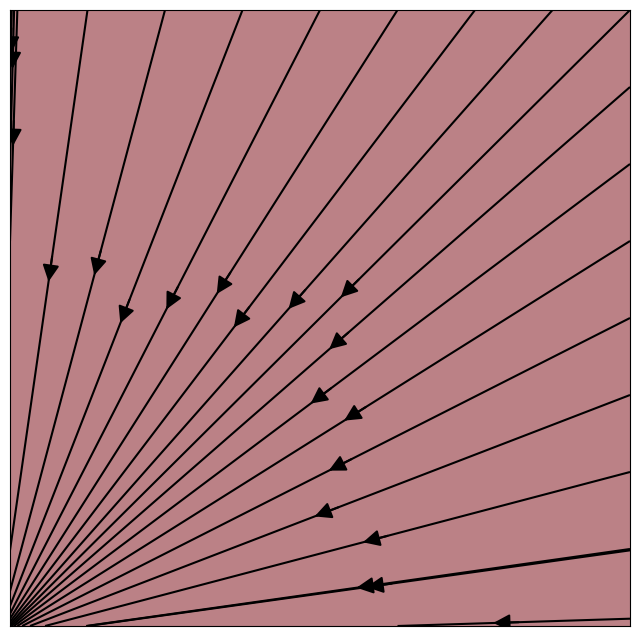

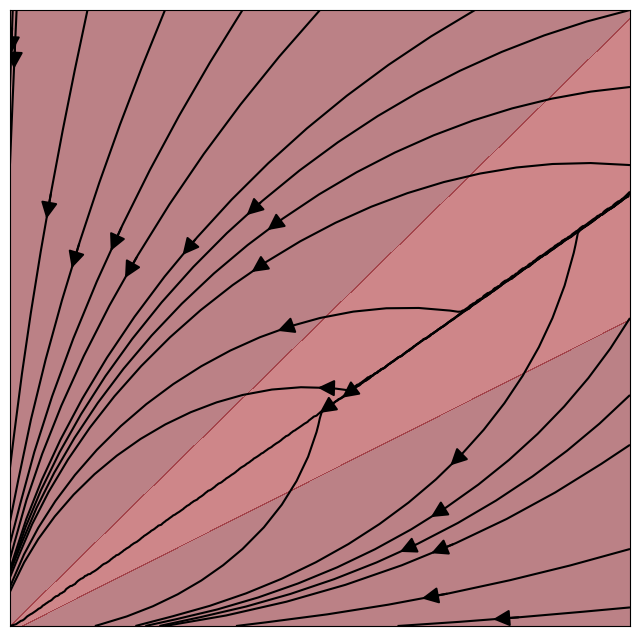

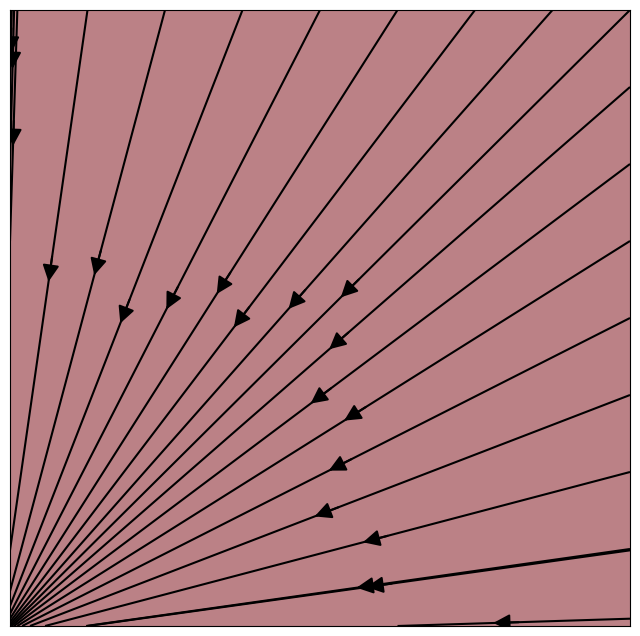

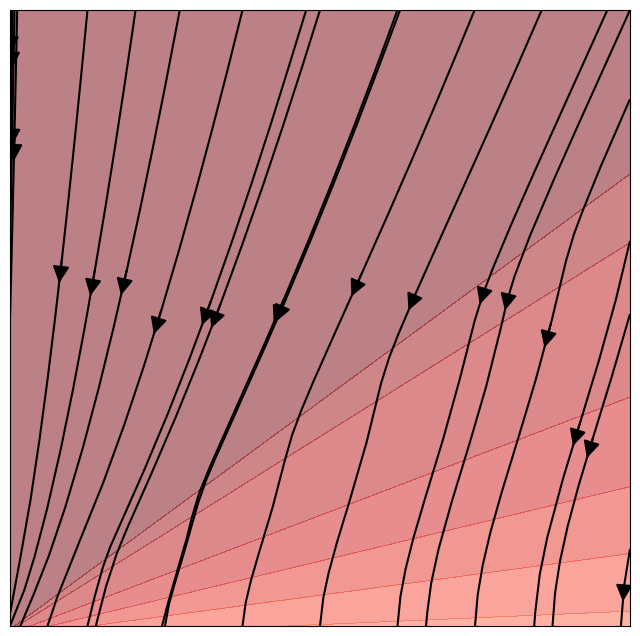

In [36]:
# Data
NPoints = 600 # Grid number of points per axis
Duration = 25 # Number of timesteps of the numerical integration
NTrials = 30 # Number of trial x point

AntennaeLength = .01 # Sensors distance, on antennae
x = np.linspace(0.1, 5, NPoints) # x axis
z = np.linspace(0.1, 5, NPoints) # z axis

X, Z = np.meshgrid(x, z) # Create 2D grid

Direction_n2_x =  np.zeros((NPoints, NPoints))
Direction_n2_z =  np.zeros((NPoints, NPoints))
Std = np.zeros((NPoints, NPoints))
for grads_i, Grad in enumerate(GradName):
    # Compute optimal direction
    for i in range(X.shape[0]):
        for j in range(X.shape[0]):
            AgentPosition = np.array([Z[i,j], X[i,j], 0])
            if np.sqrt(X[i,j]**2 + Z[i,j]**2) < 0.1:
                Direction_n2_x[i,j] = 0
                Direction_n2_z[i,j] = 0
            else:
                _, ymax, zmax, _, _, e_2 = Define_strain_eigenvectors(Grads[grads_i], e3, AgentPosition)
                Direction_n2_x[i, j] = e_2[1]
                Direction_n2_z[i, j] = e_2[0]
                Std[i, j] = np.dot(e_2, -AgentPosition/np.linalg.norm(AgentPosition))
            
    # Plot
    fig, axs = plt.subplots(nrows = 1, ncols = 1, figsize = (8, 8), sharex = 'col', sharey = 'row')
    axs.streamplot(X, Z, Direction_n2_x, Direction_n2_z, density = .3, color  = 'black', arrowsize = 2.5, broken_streamlines=False)
    #axs.contour(X, Z, Std, cmap  = 'RdBu_r', alpha = .5)
    levels = np.linspace(-1, 1.00001, 14)
    im = axs.contourf(X, Z, Std, cmap = 'Reds', levels = levels, vmin= MIN_VALUE, vmax = MAX_VALUE, alpha = 0.5)
    # PlotCircles(axs, 0.6)
    axs.set_xlim([0.1,5])
    axs.set_ylim([0.1,5])
    axs.set_xticks([])
    axs.set_yticks([])
    plt.savefig(f"Plots_NoNoise/Triangulation_theoretical"+str(GradName[grads_i])+".pdf", bbox_inches='tight')

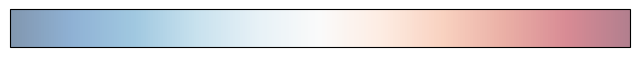

In [33]:
from matplotlib.colors import Normalize
from matplotlib.colorbar import ColorbarBase

fig, ax = plt.subplots(figsize=(8, 1))
fig.subplots_adjust(bottom=0.5)

# Create a color normalization from -1 to 1
norm = Normalize(vmin=MIN_VALUE, vmax=MAX_VALUE)

# Create a standalone colorbar
cbar = ColorbarBase(ax, cmap='RdBu_r', norm=norm, orientation='horizontal', alpha = 0.5)

# Add label and ticks (optional)
#cbar.set_label('Value')
cbar.set_ticks([])
plt.savefig(f"Plots_NoNoise/Colorbar.pdf", bbox_inches='tight')

# Plot flow and signal

In [34]:
# #118AB2 flow color

from matplotlib.colors import Normalize
def StreamPlot(ax, dx, ux, step, Flow, n, color):
    
    
    x = np.linspace(dx, ux, step)
    z = np.linspace(dx, ux, step)
  
    X,Z = np.meshgrid(x,z)
    
    e = np.array([0, 0, 1])
    
    U = np.zeros((len(x), len(x)))
    W = np.zeros((len(x), len(x)))
   
    for j in range(step):
        for i in range(step):
            Position = np.array([x[i], 0, z[j]])
            # Check if flow is gradient then project
            if Flow(e, Position).shape == (3, 3):
                flow = np.dot(Flow(e, Position), n)
            else:
                flow = Flow(e, Position)
                
            if np.linalg.norm(flow) < 1e-15:
                flow = np.zeros(3)
                
            U[j, i], _, W[j, i]  = flow
            

    stream = ax.streamplot(z, x, U, W, linewidth= 1.5, density = .5, arrowstyle = '-', arrowsize = 2.0, color = color, broken_streamlines=False) 

def StreamPlotNoise(ax, dx, ux, step, Flow, Noise, n, color):
    
    
    x = np.linspace(dx, ux, step)
    z = np.linspace(dx, ux, step)
  
    X,Z = np.meshgrid(x,z)
    
    e = np.array([0, 0, 1])
    
    U = np.zeros((len(x), len(x)))
    W = np.zeros((len(x), len(x)))
   
    for j in range(step):
        for i in range(step):
            Position = np.array([x[i], 0, z[j]])
            # Check if flow is gradient then project
            if Flow(e, Position).shape == (3, 3):
                flow = np.dot(Flow(e, Position), n)
            else:
                flow = Flow(e, Position) + Noise*np.array([0, 0,  z[j]])
                
            if np.linalg.norm(flow) < 1e-15:
                flow = np.zeros(3)
                
            U[j, i], _, W[j, i]  = flow
            

    stream = ax.streamplot(z, x, U, W, linewidth= 5, density = .6, arrowstyle = '', arrowsize = 3.0, color = color, broken_streamlines=False) 

# #118AB2 flow color

def ContourPlot(ax, dx, ux, step, Flow, n, colormap):
    
    
    x = np.linspace(dx, ux, step)
    z = np.linspace(dx, ux, step)
  
    X,Z = np.meshgrid(x,z)
    
    e = np.array([0, 0, 1])
    
    U = np.zeros((len(x), len(x)))
    W = np.zeros((len(x), len(x)))
   
    for j in range(step):
        for i in range(step):
            Position = np.array([x[i], 0, z[j]])
            # Check if flow is gradient then project
            if Flow(e, Position).shape == (3, 3):
                flow = np.dot(Flow(e, Position), n)
            else:
                flow = Flow(e, Position)
                
            if np.linalg.norm(flow) < 1e-15:
                flow = np.zeros(3)
            if np.linalg.norm(Position) < .1:
                flow = np.zeros(3)  
            U[j, i], _, W[j, i]  = flow
    
    # Create a Normalize object to control the scaling of colors

    contour = ax.contourf(X, Z, np.sqrt(U**2 + W**2), levels=1000, cmap=colormap, vmin=0.0, vmax=np.max(np.sqrt(U**2 + W**2)) )
    #cbar = plt.colorbar(contour, cmap=colormap,fraction=0.046, pad=0.04)
    #cbar.set_ticks([])


def ContourPlotNoise(ax, dx, ux, step, Flow, Noise, n, colormap):
    
    
    x = np.linspace(dx, ux, step)
    z = np.linspace(dx, ux, step)
  
    X,Z = np.meshgrid(x,z)
    
    e = np.array([0, 0, 1])
    
    U = np.zeros((len(x), len(x)))
    W = np.zeros((len(x), len(x)))
   
    for j in range(step):
        for i in range(step):
            Position = np.array([x[i], 0, z[j]])
            # Check if flow is gradient then project
            if Flow(e, Position).shape == (3, 3):
                flow = np.dot(Flow(e, Position), n)
            else:
                flow = Flow(e, Position) + Noise*np.array([0, 0,  z[j]])
                
            if np.linalg.norm(flow) < 1e-15:
                flow = np.zeros(3)
            if np.linalg.norm(Position) < .95:
                flow = np.zeros(3)  
            U[j, i], _, W[j, i]  = flow
    
    # Create a Normalize object to control the scaling of colors
    
    contour = ax.contourf(X, Z, np.sqrt(U**2 + W**2), levels=1000, cmap=colormap, vmin=0.0, vmax=np.max(np.sqrt(U**2 + W**2)) )
    #cbar = plt.colorbar(contour, cmap=colormap,fraction=0.046, pad=0.04)
    #cbar.set_ticks([])